# Práctica 4. Procesamiento audio
## Ejercicio 2: 
Construir una pequeña aplicación que permita operar con diferentes filtros (con un selector)  y trabajar con varios umbrales. (uno para los filtros pasa-bajo y pasa-alto y dos para los filtros pasa-banda  y  rechaza-banda).  Demuestre  su  funcionalidad  con  señales  ruidosas.  Muestre  en  cada  filtrado  la  señal  original y filtrada en el dominio temporal y en el dominio de la frecuencia. 



(APORTES ADICIONALES) 

(a)  Reproducir la nota ruidosa original y filtrada a través de la aplicación para comparar resultados y 
cambiar parámetros en tiempo real (o casi). 

(b)  Aportes  adicionales  (como  uso  del  micrófono,  experimentar  con  implementaciones  de  filtros  diferentes)

Ruido añadido con nivel: 0.1
Filtro Pasa-Bajo aplicado: fc=1000 Hz


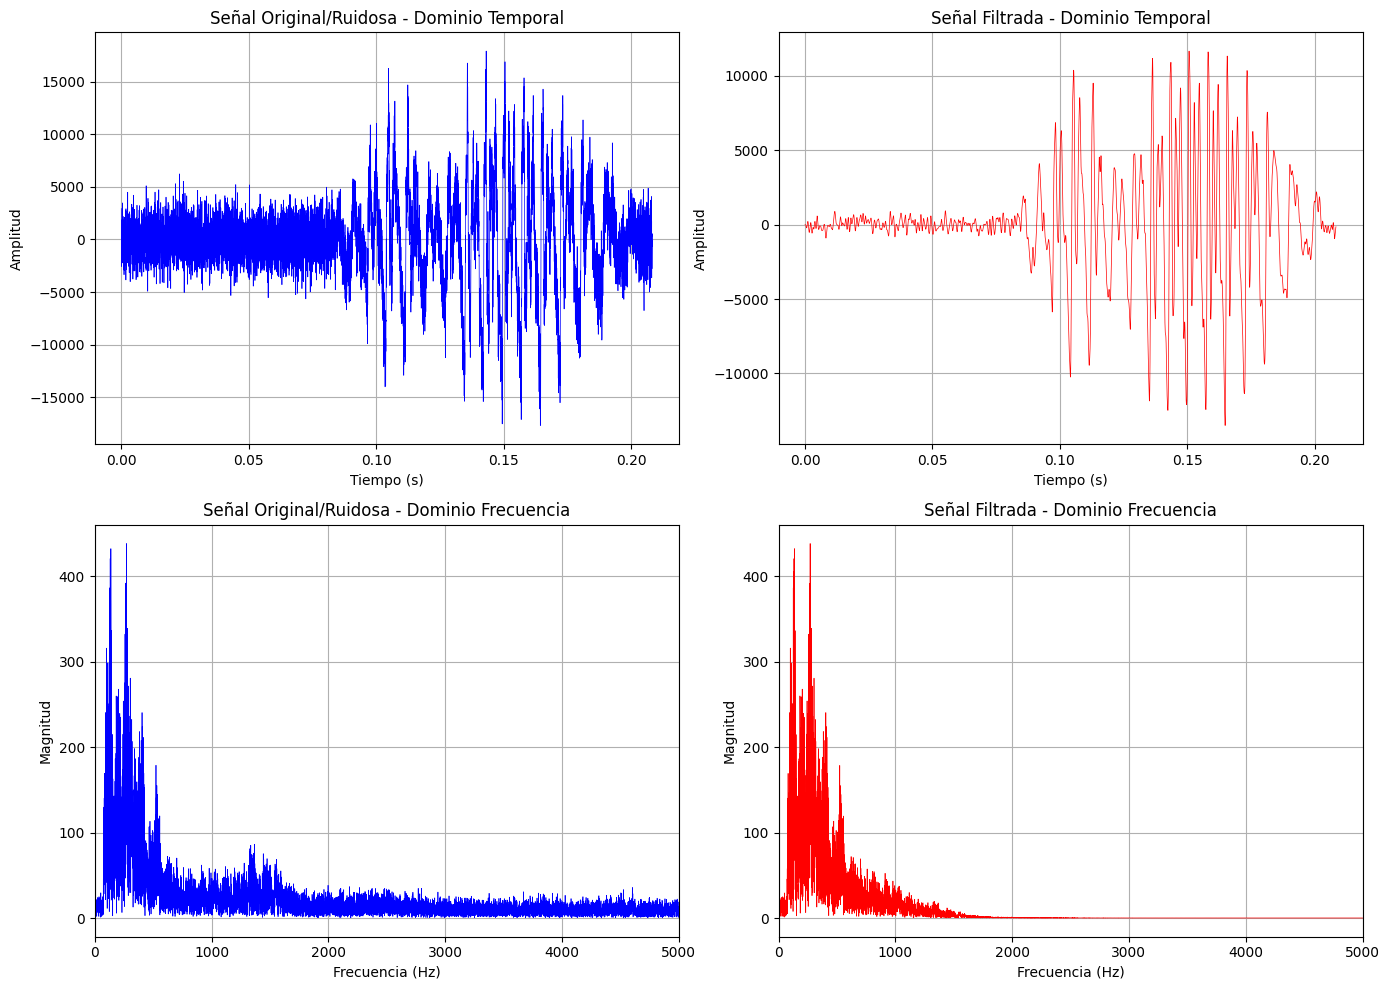

Señal ruidosa guardada: data/E2/senalruidosa.wav
Señal filtrada guardada: data/E2/senalruidosa_filtrado_pasobajo.wav
=== DEMOSTRACIÓN DE FILTROS DE AUDIO ===

1. FILTRO PASA-BAJO
--------------------------------------------------
Ruido añadido con nivel: 0.15
Filtro Pasa-Bajo aplicado: fc=1000 Hz


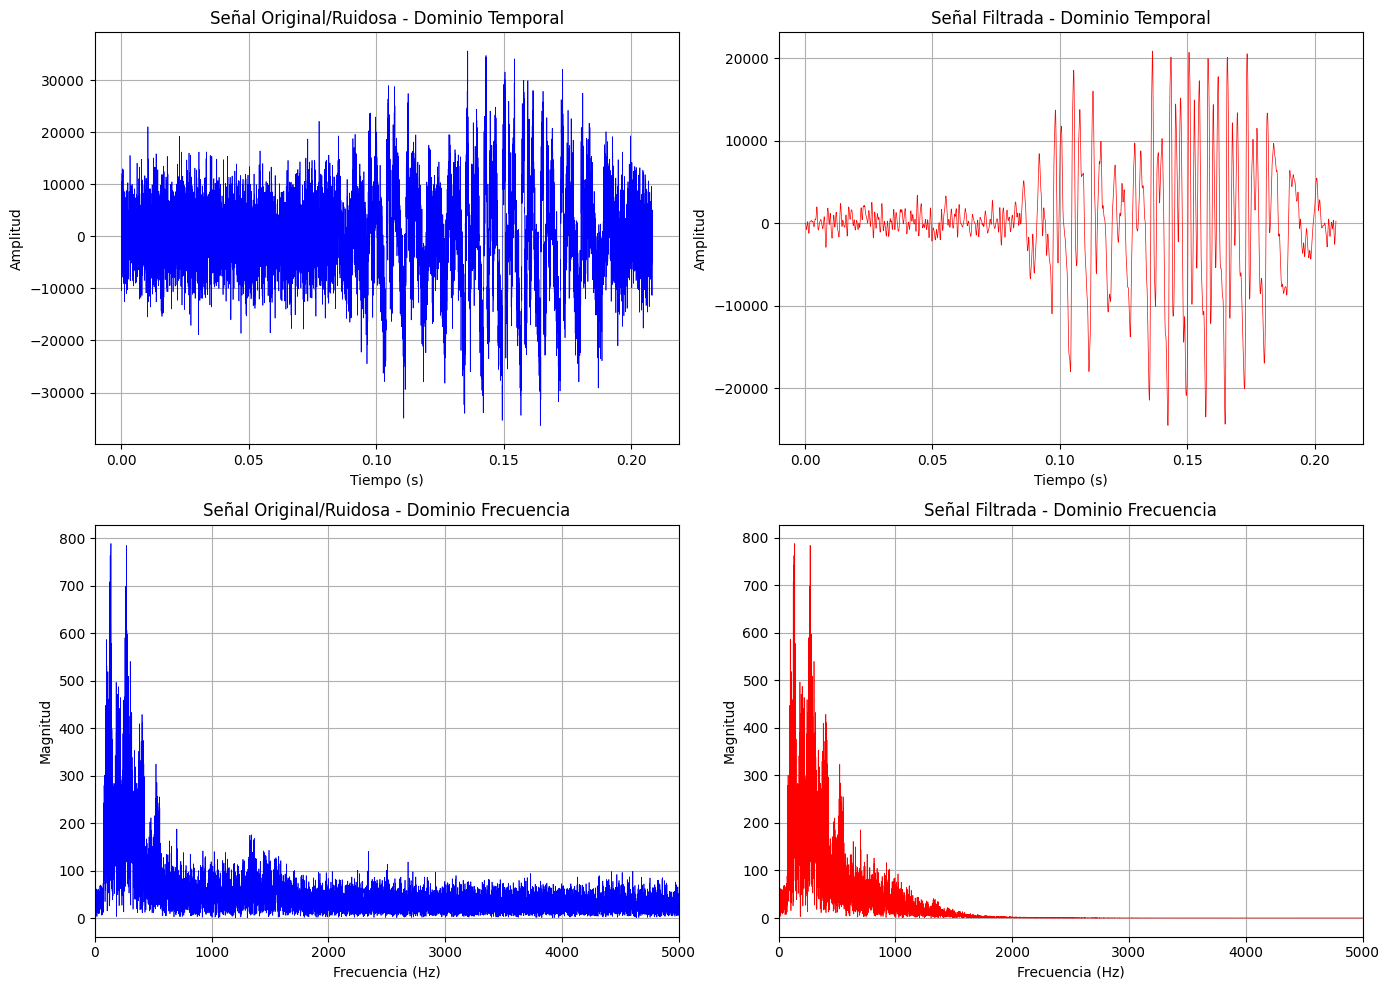

Señal ruidosa guardada: output/E2/ruidosa.wav
Señal filtrada guardada: output/E2/filtrada_pasobajo.wav

2. FILTRO PASA-ALTO
--------------------------------------------------
Ruido añadido con nivel: 0.15
Filtro Pasa-Alto aplicado: fc=500 Hz


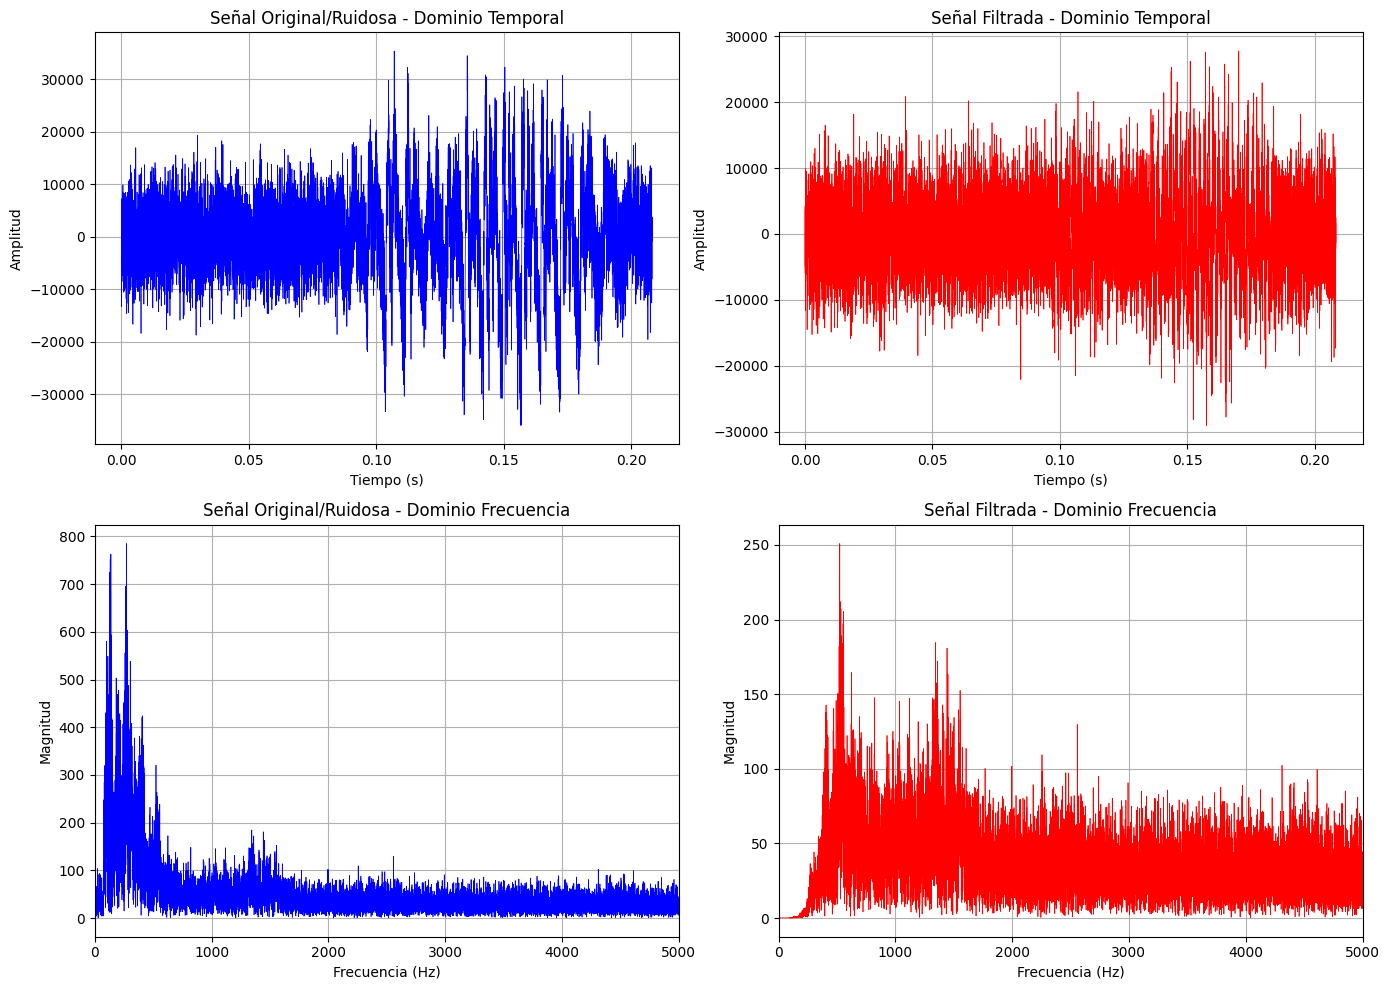

Señal ruidosa guardada: output/E2/ruidosa.wav
Señal filtrada guardada: output/E2/filtrada_pasoalto.wav

3. FILTRO PASA-BANDA
--------------------------------------------------
Ruido añadido con nivel: 0.15
Filtro Pasa-Banda aplicado: fc1=300 Hz, fc2=2000 Hz


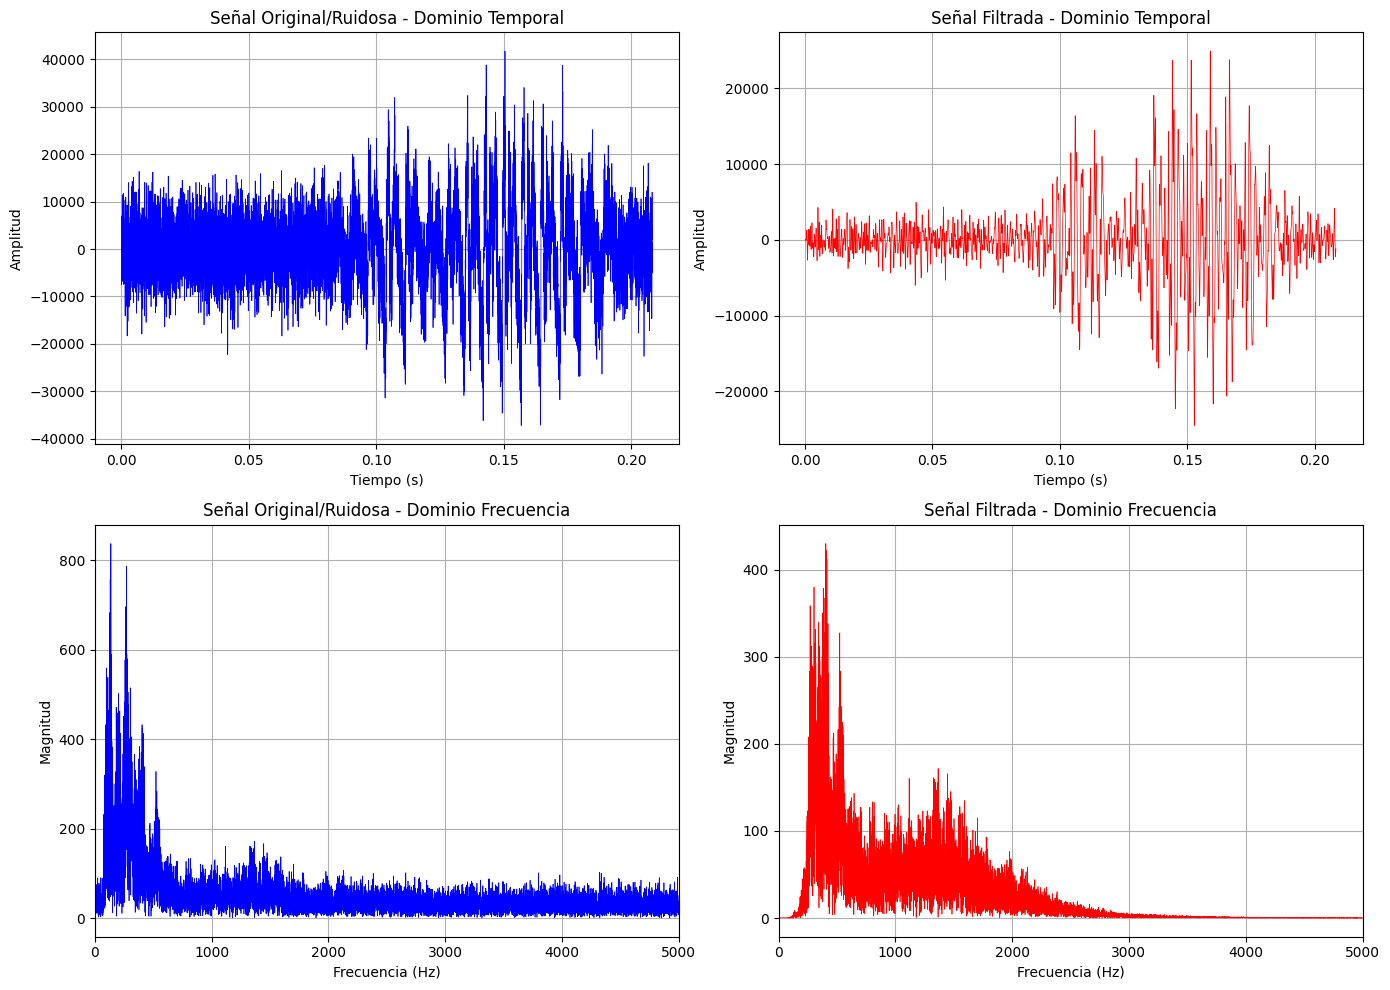

Señal ruidosa guardada: output/E2/ruidosa.wav
Señal filtrada guardada: output/E2/filtrada_pasobanda.wav

4. FILTRO RECHAZA-BANDA
--------------------------------------------------
Ruido añadido con nivel: 0.15
Filtro Rechaza-Banda aplicado: fc1=800 Hz, fc2=1200 Hz


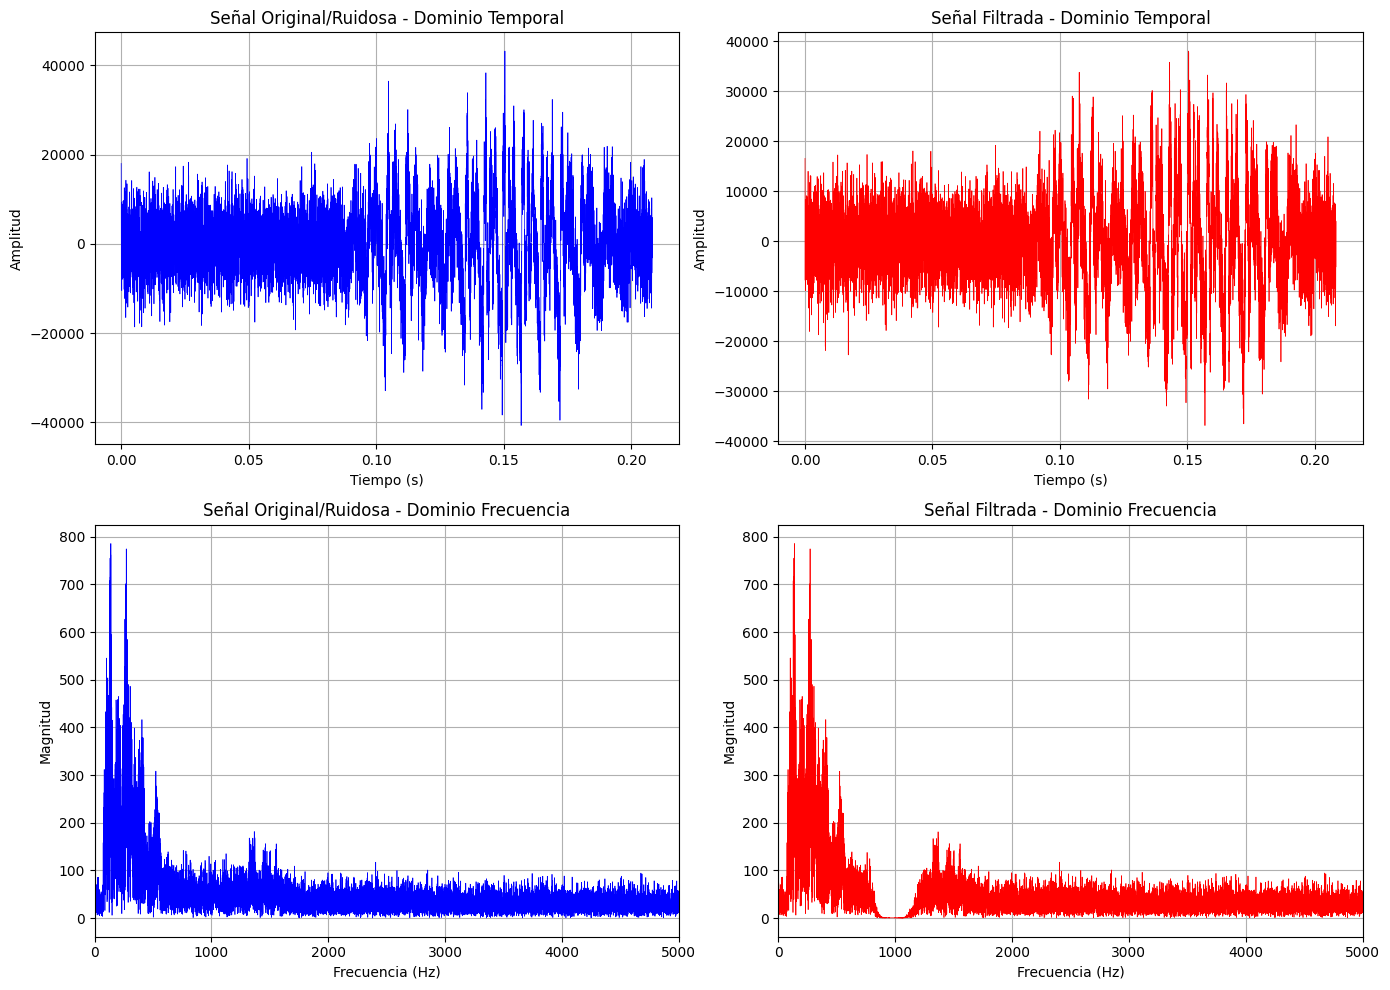

Señal ruidosa guardada: output/E2/ruidosa.wav
Señal filtrada guardada: output/E2/filtrada_rechazabanda.wav


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.io import wavfile
from scipy.fft import fft, fftfreq

class AudioFilterApp:
    def __init__(self, audio_file):
        self.sr, self.y = wavfile.read(audio_file)
        
        if len(self.y.shape) > 1:
            self.y = self.y.mean(axis=1)
        
        self.y = self.y.astype(float)
        self.y_ruidosa = None
        self.y_filtrada = None
        
    def add_noise(self, noise_level=0.1):
        ruido = np.random.normal(0, 1.0, self.y.shape)
        max_val = np.max(np.abs(self.y))
        self.y_ruidosa = self.y + noise_level * max_val * ruido
        print(f"Ruido añadido con nivel: {noise_level}")
        
    def butter_lowpass(self, cutoff, order=5):
        nyq = 0.5 * self.sr
        normal_cutoff = cutoff / nyq
        b, a = butter(order, normal_cutoff, btype='low', analog=False)
        return b, a
    
    def butter_highpass(self, cutoff, order=5):
        nyq = 0.5 * self.sr
        normal_cutoff = cutoff / nyq
        b, a = butter(order, normal_cutoff, btype='high', analog=False)
        return b, a
    
    def butter_bandpass(self, lowcut, highcut, order=5):
        nyq = 0.5 * self.sr
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band', analog=False)
        return b, a
    
    def butter_bandstop(self, lowcut, highcut, order=5):
        nyq = 0.5 * self.sr
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='bandstop', analog=False)
        return b, a
    
    def apply_filter(self, filter_type='lowpass', cutoff1=1000, cutoff2=3000, order=5):
        signal = self.y_ruidosa if self.y_ruidosa is not None else self.y
        
        if filter_type == 'lowpass':
            b, a = self.butter_lowpass(cutoff1, order)
            print(f"Filtro Pasa-Bajo aplicado: fc={cutoff1} Hz")
        elif filter_type == 'highpass':
            b, a = self.butter_highpass(cutoff1, order)
            print(f"Filtro Pasa-Alto aplicado: fc={cutoff1} Hz")
        elif filter_type == 'bandpass':
            b, a = self.butter_bandpass(cutoff1, cutoff2, order)
            print(f"Filtro Pasa-Banda aplicado: fc1={cutoff1} Hz, fc2={cutoff2} Hz")
        elif filter_type == 'bandstop':
            b, a = self.butter_bandstop(cutoff1, cutoff2, order)
            print(f"Filtro Rechaza-Banda aplicado: fc1={cutoff1} Hz, fc2={cutoff2} Hz")
        else:
            raise ValueError("Tipo de filtro no válido")
        
        self.y_filtrada = lfilter(b, a, signal)
        return self.y_filtrada
    
    def plot_results(self, show_frequency=True):
        signal = self.y_ruidosa if self.y_ruidosa is not None else self.y
        
        if show_frequency:
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))
            
            samples_to_plot = min(10000, len(signal))
            time = np.arange(samples_to_plot) / self.sr
            
            axes[0, 0].plot(time, signal[:samples_to_plot], 'b-', linewidth=0.5)
            axes[0, 0].set_title('Señal Original/Ruidosa - Dominio Temporal')
            axes[0, 0].set_xlabel('Tiempo (s)')
            axes[0, 0].set_ylabel('Amplitud')
            axes[0, 0].grid(True)
            
            N = len(signal)
            yf = fft(signal)
            xf = fftfreq(N, 1/self.sr)[:N//2]
            magnitude = 2.0/N * np.abs(yf[:N//2])
            
            axes[1, 0].plot(xf, magnitude, 'b-', linewidth=0.5)
            axes[1, 0].set_title('Señal Original/Ruidosa - Dominio Frecuencia')
            axes[1, 0].set_xlabel('Frecuencia (Hz)')
            axes[1, 0].set_ylabel('Magnitud')
            axes[1, 0].set_xlim(0, min(5000, self.sr/2))
            axes[1, 0].grid(True)
            
            if self.y_filtrada is not None:
                axes[0, 1].plot(time, self.y_filtrada[:samples_to_plot], 'r-', linewidth=0.5)
                axes[0, 1].set_title('Señal Filtrada - Dominio Temporal')
                axes[0, 1].set_xlabel('Tiempo (s)')
                axes[0, 1].set_ylabel('Amplitud')
                axes[0, 1].grid(True)
                
                N = len(self.y_filtrada)
                yf = fft(self.y_filtrada)
                xf = fftfreq(N, 1/self.sr)[:N//2]
                magnitude = 2.0/N * np.abs(yf[:N//2])
                
                axes[1, 1].plot(xf, magnitude, 'r-', linewidth=0.5)
                axes[1, 1].set_title('Señal Filtrada - Dominio Frecuencia')
                axes[1, 1].set_xlabel('Frecuencia (Hz)')
                axes[1, 1].set_ylabel('Magnitud')
                axes[1, 1].set_xlim(0, min(5000, self.sr/2))
                axes[1, 1].grid(True)
            
            plt.tight_layout()
        else:
            plt.figure(figsize=(12, 8))
            
            plt.subplot(3, 1, 1)
            plt.plot(self.y[:10000])
            plt.title('Señal Original')
            plt.ylabel('Amplitud')
            plt.grid(True)
            
            plt.subplot(3, 1, 2)
            plt.plot(signal[:10000])
            plt.title('Señal con Ruido')
            plt.ylabel('Amplitud')
            plt.grid(True)
            
            if self.y_filtrada is not None:
                plt.subplot(3, 1, 3)
                plt.plot(self.y_filtrada[:10000])
                plt.title('Señal Filtrada')
                plt.xlabel('Muestras')
                plt.ylabel('Amplitud')
                plt.grid(True)
            
            plt.tight_layout()
        
        plt.show()
    
    def save_audio(self, output_noisy='senalruidosa.wav', output_filtered='senalruidosa_filtrado.wav'):
        if self.y_ruidosa is not None:
            y_noisy_normalized = np.int16(self.y_ruidosa / np.max(np.abs(self.y_ruidosa)) * 32767)
            wavfile.write(output_noisy, self.sr, y_noisy_normalized)
            print(f"Señal ruidosa guardada: {output_noisy}")
        
        if self.y_filtrada is not None:
            y_filtered_normalized = np.int16(self.y_filtrada / np.max(np.abs(self.y_filtrada)) * 32767)
            wavfile.write(output_filtered, self.sr, y_filtered_normalized)
            print(f"Señal filtrada guardada: {output_filtered}")


def demo_filtros(audio_file):
    
    print("=== DEMOSTRACIÓN DE FILTROS DE AUDIO ===\n")
    
    print("1. FILTRO PASA-BAJO")
    print("-" * 50)
    app = AudioFilterApp(audio_file)
    app.add_noise(noise_level=0.15)
    app.apply_filter(filter_type='lowpass', cutoff1=1000, order=5)
    app.plot_results(show_frequency=True)
    app.save_audio(f'{output_dir}ruidosa.wav', f'{output_dir}filtrada_pasobajo.wav')
    
    print("\n2. FILTRO PASA-ALTO")
    print("-" * 50)
    app2 = AudioFilterApp(audio_file)
    app2.add_noise(noise_level=0.15)
    app2.apply_filter(filter_type='highpass', cutoff1=500, order=5)
    app2.plot_results(show_frequency=True)
    app2.save_audio(f'{output_dir}ruidosa.wav', f'{output_dir}filtrada_pasoalto.wav')
    
    print("\n3. FILTRO PASA-BANDA")
    print("-" * 50)
    app3 = AudioFilterApp(audio_file)
    app3.add_noise(noise_level=0.15)
    app3.apply_filter(filter_type='bandpass', cutoff1=300, cutoff2=2000, order=5)
    app3.plot_results(show_frequency=True)
    app3.save_audio(f'{output_dir}ruidosa.wav', f'{output_dir}filtrada_pasobanda.wav')
    
    print("\n4. FILTRO RECHAZA-BANDA")
    print("-" * 50)
    app4 = AudioFilterApp(audio_file)
    app4.add_noise(noise_level=0.15)
    app4.apply_filter(filter_type='bandstop', cutoff1=800, cutoff2=1200, order=5)
    app4.plot_results(show_frequency=True)
    app4.save_audio(f'{output_dir}ruidosa.wav', f'{output_dir}filtrada_rechazabanda.wav')


def uso_simple(dir, audio_file):
    app = AudioFilterApp(f"{dir}{audio_file}")
    app.add_noise(noise_level=0.1)
    app.apply_filter(filter_type='lowpass', cutoff1=1000, order=5)
    app.plot_results(show_frequency=True)
    app.save_audio(f"{dir}senalruidosa.wav", f"{dir}senalruidosa_filtrado_pasobajo.wav")


if __name__ == "__main__":
    dir = "data/E2/"
    output_dir = "output/E2/"

    os.makedirs(dir, exist_ok=True)
    os.makedirs(output_dir, exist_ok=True)

    uso_simple(dir, 'un_archivo_audio.wav')
    demo_filtros(f"{dir}senalruidosa.wav")